# Two Neuron Day 8 (07/01/2026)
***Feature Extraction from Spike Trains***

## Concept
- Excitatory synapse -> increases postsynaptic activity
- Inhibitory synapse -> decreases postsynaptic activity

**Neuron A**

In [13]:
import numpy as np
import matplotlib.pyplot as plt
#Time parameters
dt=0.1
T=100
time=np.arange(0,T,dt)

# Neuron A parameters
V_rest_A=-65
V_A=np.zeros(len(time))
V_A[0]=V_rest_A

#Input Current (constant)
I_A = 6
tau_A=10

# Spikes A
V_th_A = -63
V_reset_A = -65
spikes_A= np.zeros(len(time))

#Refractory period 
refractory_period_A = 2
refractory_steps_A = int(refractory_period_A / dt)
refractory_timer_A= 0

#Voltage update loop
for t in range(1,len(time)):
    if refractory_timer_A >0:
        V_A[t] = V_reset_A
        refractory_timer_A -= 1

    else:
        dV_A= (-(V_A[t-1] - V_rest_A ) + I_A) * (dt/tau_A)
        V_A[t] = V_A[t-1] + dV_A

        if V_A[t] >= V_th_A :
            spikes_A[t] = 1
            V_A[t] = V_reset_A
            refractory_timer_A = refractory_steps_A

#Firing rate calculation
total_spikes_A = np.sum(spikes_A)
total_time_sec_A= T/1000

firing_rate_A = total_spikes_A / total_time_sec_A
firing_rate_A

np.float64(160.0)

**Spike Count Neuron A**

In [14]:
spike_count_A = np.sum(spikes_A)
spike_count_A

np.float64(16.0)

**Neuron A Graph**

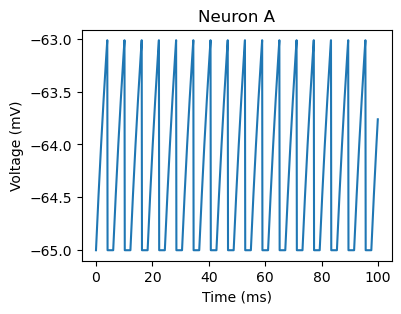

In [5]:
plt.figure(figsize=(4,3))
plt.plot(time,V_A)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron A")
plt.show()

**Spike Train Neuron A**

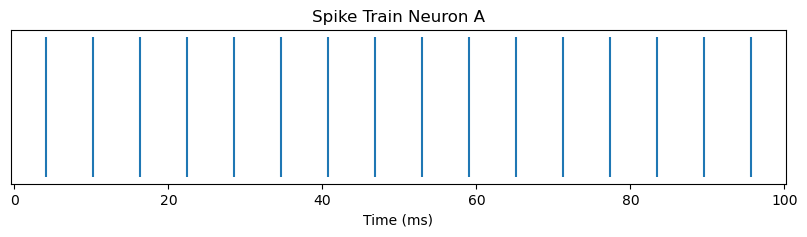

In [6]:
spike_times_A = time[spikes_A == 1]

plt.figure(figsize=(10,2))
plt.vlines(spike_times_A,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron A")
plt.show()

**Neuron B**

In [7]:
#Neuron A parameters 
V_rest_B = -65
V_B = np.zeros(len(time))
V_B[0] = V_rest_B

#Input Current (comes from Neuron A) 
# Synapthic connection from A-> B
w_AB = 15
I_B= np.zeros(len(time))
syn_current_B = np.zeros(len(time))

#Inhibitory synapse from A-> B
w_AiB = 2.5
syn_current_inh_B = np.zeros(len(time))

#Spikes
V_th_B = -63
V_reset_B = -65
spikes_B = np.zeros(len(time))

#Refractory period
refractory_period_B = 2
refractory_steps_B = int(refractory_period_B / dt)
refractory_timer_B =0

# Voltage update loop for Neuron B
for t in range(1,len(time)):
    #Synapthic input from Neuron A
    syn_current_B[t] = syn_current_B[t-1] * 0.9 + w_AB * spikes_A[t-1]
    syn_current_inh_B[t] = syn_current_inh_B[t-1]*0.9 + w_AiB * spikes_A[t-1]
    I_B[t] = syn_current_B[t] - syn_current_inh_B[t]


    if refractory_timer_B>0:
        V_B[t] = V_reset_B
        refractory_timer_B-=1

    else:
        dV_B = (-(V_B[t-1] - V_rest_B) + I_B[t]) * (dt / tau_A)
        V_B[t] = V_B[t-1] + dV_B

        if V_B[t] >= V_th_B:
            spikes_B[t]=1
            V_B[t] = V_reset_B
            refractory_timer_B = refractory_steps_B

#Firing rate calculation
total_spikes_B = np.sum(spikes_B)
total_time_sec_B= T/1000

firing_rate_B = total_spikes_B / total_time_sec_B
firing_rate_B

np.float64(40.0)

**Spike Count Neuron B**

In [18]:
spike_count_B = np.sum(spikes_B)
spike_count_B

np.float64(4.0)

**Neuron B Graph**

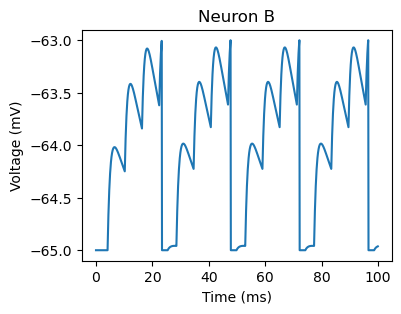

In [8]:
plt.figure(figsize=(4,3))
plt.plot(time,V_B)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron B")
plt.show()

**Spike Train Neuron B**

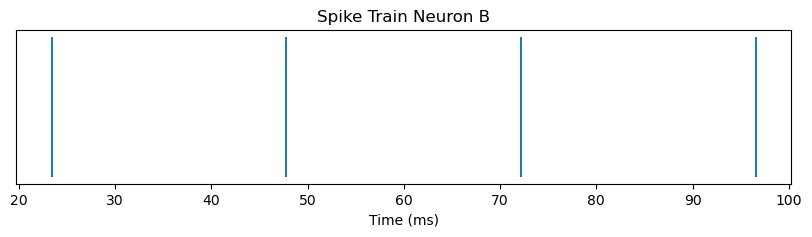

In [9]:
spike_times_B = time[spikes_B == 1]

plt.figure(figsize = (10,2))
plt.vlines(spike_times_B,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron B")
plt.show()

**Inter-Spike Interal (ISI)**

In [43]:
spike_times_A = time[spikes_A == 1]
spike_times_B = time[spikes_B == 1]

isi_A = np.diff(spike_times_A)
isi_B = np.diff(spike_times_B)

len(isi_A),len(isi_B)

(15, 3)

In [54]:
# mean ISI
mean_isi_A = np.mean(isi_A)
mean_isi_B = np.mean(isi_B)

mean_isi_A,mean_isi_B

(np.float64(6.1), np.float64(24.400000000000002))

In [55]:
# isi variance
std_isi_A = np.std(isi_A)
std_isi_B = np.std(isi_B)

std_isi_A,std_isi_B

(np.float64(4.96639214822091e-15), np.float64(2.9007785717557725e-15))

In [58]:
# Coefficient of Variations (CV)
cv_A = np.std(isi_A)/ np.mean(isi_A)
cv_B = np.std(isi_B)/ np.mean(isi_B)
cv_A,cv_B

(np.float64(8.141626472493295e-16), np.float64(1.188843676949087e-16))

**Plot ISI for A**

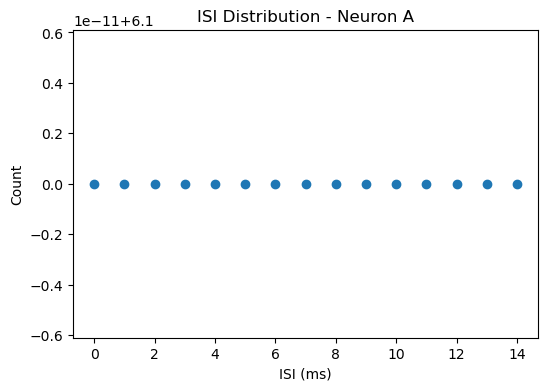

In [56]:
plt.figure(figsize=(6,4))
plt.plot(isi_A,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron A")
plt.show()

Plotting inter-spike intervals (ISI) as individual values shows that all ISIs collapse to a single constant value.
This indicates highly regular, tonic firing behavior of the neuron under constant input.
Such deterministic firing patterns are characteristic of LIF neurons without noise or time-varying inputs.
This regular baseline serves as a reference for later comparisons involving inhibition, noise, or modulation.

**Plot ISI for B**

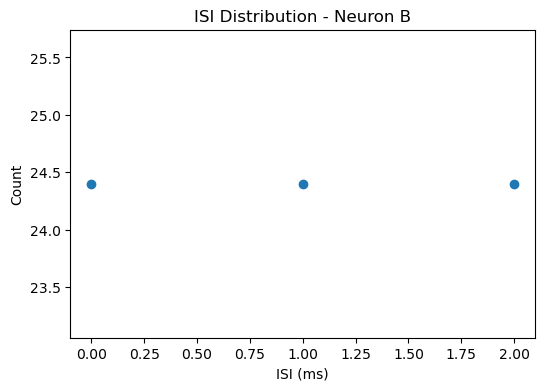

In [57]:
plt.figure(figsize=(6,4))
plt.plot(isi_B,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron B")
plt.show()

## Observation – Spike Train Feature Analysis (Phase 4, Day 1)

The spike trains generated by the LIF neuron models were analyzed using spike count, firing rate, and inter-spike interval (ISI). Neuron A produced a sufficient number of spikes, allowing ISI extraction and analysis. Plotting ISI values revealed that all intervals collapsed to a single constant value, indicating highly regular (tonic) firing behavior. This regularity arises from constant input current and the absence of noise in the model, resulting in deterministic spike timing.

Neuron B generated fewer spikes, leading to a small number of ISIs, making histogram-based ISI analysis uninformative. In such cases, spike count and firing rate serve as more appropriate descriptors of neural activity. Overall, these results demonstrate that spike-based features effectively capture both activity level and temporal firing structure, providing a compact numerical representation of neural dynamics.

Mean ISI and ISI variability analysis for Neuron A show extremely low variance, resulting in a coefficient of variation close to zero.
This confirms highly regular, deterministic firing under constant input conditions.

The neuron exhibits deterministic firing behavior, characterized by highly regular spike timing and nearly constant inter-spike intervals.
This arises from constant input current and the absence of stochastic components in the model.
Such deterministic firing serves as a baseline reference for later comparisons with irregular firing patterns that emerge under noisy or time-varying inputs.

